In [22]:
SITE     = "site1"       
FLOOR    = "F4"           
DATA_DIR = "./indoor_data" 

In [10]:
import subprocess, sys, os
import glob
import numpy as np
import matplotlib.pyplot as plt


# Install packages
subprocess.run([sys.executable, "-m", "pip", "install",
                "numpy", "scipy", "matplotlib", "-q"], check=True)

Packages ready.


In [23]:
def parse_trace(filepath):
    waypoints, beacons = [], []
    with open(filepath, "r", errors="ignore") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3 or line.startswith("#"):
                continue
            ts, kind = int(parts[0]), parts[1]
            if kind == "TYPE_WAYPOINT" and len(parts) >= 4:
                waypoints.append((ts, float(parts[2]), float(parts[3])))
            elif kind == "TYPE_BEACON" and len(parts) >= 8:
                beacons.append((ts, f"{parts[2]}_{parts[3]}_{parts[4]}", float(parts[6])))
    return waypoints, beacons

def match_to_position(waypoints, beacons):
    if not waypoints or not beacons:
        return []
    wp_ts = np.array([w[0] for w in waypoints])
    wp_xy = np.array([(w[1], w[2]) for w in waypoints])
    return [(*wp_xy[np.argmin(np.abs(wp_ts - ts))], rssi, bid)
            for ts, bid, rssi in beacons]

floor_path  = os.path.join(DATA_DIR, "data", SITE, FLOOR, "path_data_files")
trace_files = glob.glob(os.path.join(floor_path, "*.txt"))
print(f"Found {len(trace_files)} trace file(s) for {SITE}/{FLOOR}")

all_readings = []
for fp in trace_files:
    wps, bkns = parse_trace(fp)
    all_readings.extend(match_to_position(wps, bkns))

print(f"Total beacon readings: {len(all_readings)}")

Found 122 trace file(s) for site1/F4
Total beacon readings: 20619


In [ ]:
from collections import Counter

counts     = Counter(r[3] for r in all_readings)
top5       = counts.most_common(5)

print("Top 5 beacons by reading count:")
for bid, n in top5:
    print(f"  {bid}  →  {n} readings")

# Auto-select top beacon
BEACON_ID = top5[0][0]
print(f"\nSelected: {BEACON_ID}")

Top 5 beacons by reading count:
  9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0  →  16097 readings
  FDA50693-A4E2-4FB1-AFCF-C6EB07647825_10073_61418  →  4264 readings
  48F8C9EF-AEF9-482D-987F-3752F1C51DA1_22_40969  →  68 readings
  6B76E28A-6FA2-48C9-8502-C1DAA388AB2C_45651_11327  →  62 readings
  48F8C9EF-AEF9-482D-987F-3752F1C51DA1_20_31450  →  62 readings

Selected: 9195B3AD-A9D0-4500-85FF-9FB0F65A5201_0_0


Saved → ibeacon_heatmap_site1_F4.png


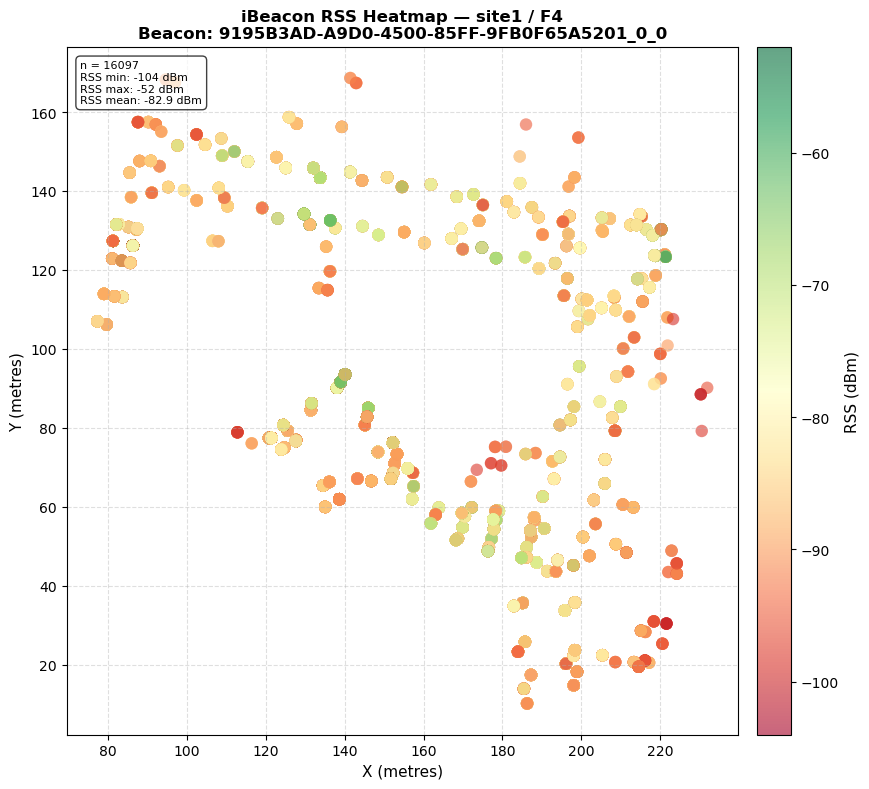

In [28]:
# filter to chosen beacon
rows = [(x, y, rssi) for (x, y, rssi, bid) in all_readings if bid == BEACON_ID]
xs   = np.array([r[0] for r in rows])
ys   = np.array([r[1] for r in rows])
rss  = np.array([r[2] for r in rows])

# plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(xs, ys, c=rss, cmap="RdYlGn",
                s=80, linewidths=0, alpha=0.6,
                vmin=rss.min(), vmax=rss.max())

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("RSS (dBm)", fontsize=11)

# Labels & formatting
ax.set_xlabel("X (metres)", fontsize=11)
ax.set_ylabel("Y (metres)", fontsize=11)
ax.set_title(
    f"iBeacon RSS Heatmap — {SITE} / {FLOOR}\nBeacon: {BEACON_ID}",
    fontsize=12, fontweight="bold"
)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.4)

# Stats box
stats_txt = (f"n = {len(xs)}\n"
             f"RSS min: {rss.min():.0f} dBm\n"
             f"RSS max: {rss.max():.0f} dBm\n"
             f"RSS mean: {rss.mean():.1f} dBm")
ax.text(0.02, 0.98, stats_txt, transform=ax.transAxes,
        fontsize=8, va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.75))

plt.tight_layout()
out_path = f"ibeacon_heatmap_{SITE}_{FLOOR}.png"
plt.savefig(out_path, dpi=150)
print(f"Saved → {out_path}")
plt.show()

In [26]:
#superimpose on floorplan

import json, glob
from PIL import Image


with open("./indoor_data/data/site1/F4/floor_info.json") as f:  # adjust filename
    meta = json.load(f)
print(meta)

{'map_info': {'height': 179.22412617881955, 'width': 241.6437586249384}}


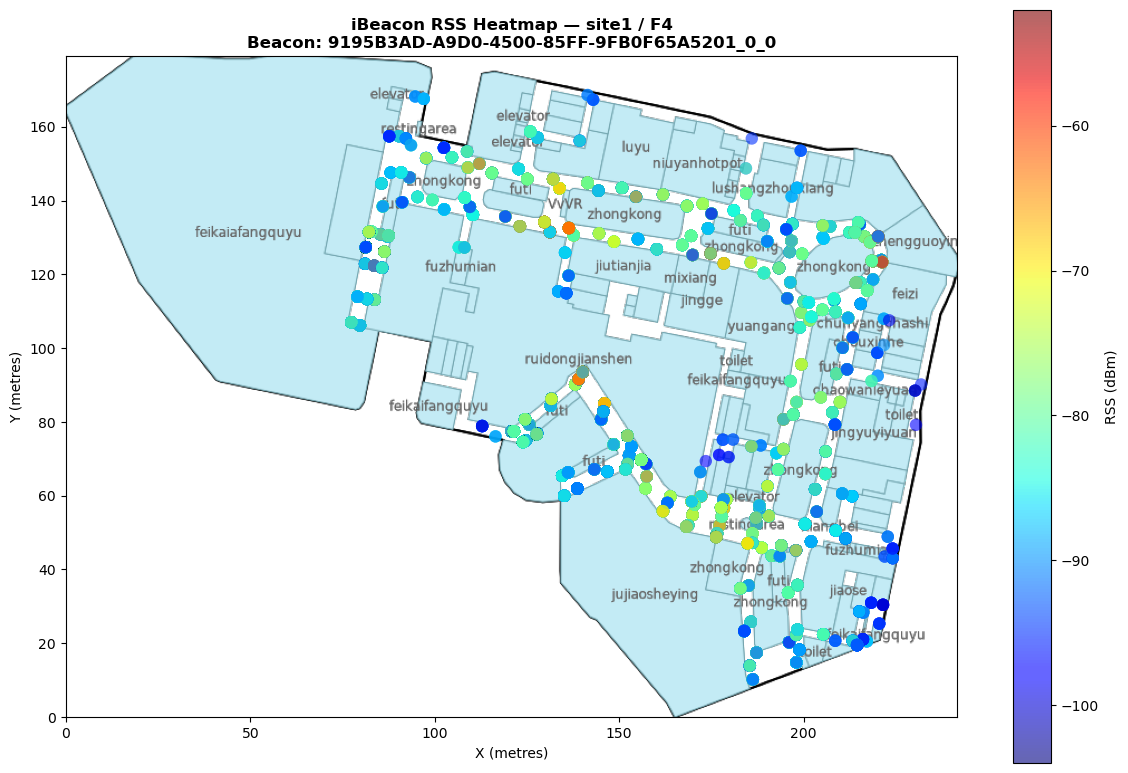

In [27]:

meta = {'map_info': {'height': 179.22412617881955, 'width': 241.6437586249384}}

floor_img = Image.open("./indoor_data/data/"+SITE+"/"+FLOOR+"/floor_image.png")

x_min, x_max = 0, meta['map_info']['width']
y_min, y_max = 0, meta['map_info']['height']

fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(floor_img, extent=[x_min, x_max, y_min, y_max], origin="upper")

sc = ax.scatter(xs, ys, c=rss, cmap="jet",
                s=80, linewidths=0, alpha=0.6,
                vmin=rss.min(), vmax=rss.max())

fig.colorbar(sc, label="RSS (dBm)")
ax.set_xlabel("X (metres)")
ax.set_ylabel("Y (metres)")
ax.set_title(f"iBeacon RSS Heatmap — {SITE} / {FLOOR}\nBeacon: {BEACON_ID}",
             fontweight="bold")

plt.tight_layout()
plt.savefig(f"ibeacon_heatmap_{SITE}_{FLOOR}_floorplan.png", dpi=150)
plt.show()